# Repeat Shopper — Monthly Category Sequence Analysis
**What did each shopper buy, month by month — and what changed?**

Aligns every shopper to a relative journey timeline (Month 1 = first purchase month).

**Outputs**
1. `shopper_monthly_sequence.parquet/csv` — one row per shopper × journey month, listing every subdept bought that month
2. `shopper_category_matrix.parquet/csv` — wide binary matrix: shopper × subdept, value = first journey month they bought it (0 = never)
3. `aggregate_adoption_curve.csv` — % of shoppers who bought each subdept by journey month N
4. Four charts: adoption curves, new-vs-repeat category heatmap, first-time adoption waterfall, category drop-off funnel

**Inputs required**
- `combined_shoppers.parquet`
- `baby_shopper_profiles_phase1.parquet`

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2C7BB6','#D7191C','#1A9641','#FDAE61','#762A83','#F46D43',
           '#4DAC26','#E66101','#5E3C99','#FDB863','#B2ABD2','#008837']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi':130,'axes.titlesize':12,
                     'axes.titleweight':'bold','figure.titlesize':13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 120)

PROMO_SUBCLASS   = 'md promo'
PROMO_SUBDEPTS   = {'iw promotions', 'iaf clearance', 'iaf promotions'}
MAX_JOURNEY_MONTHS = 12

print('Setup complete.')

Setup complete.


## 2. Load Raw Transactions & Filter to Repeat Shoppers

Same promo filter + date parsing as Phase 1. We carry over the `customer_id` integer encoding from the Phase 1 profile so IDs are consistent across notebooks.

In [4]:
# ── 2.1 Phase 1 profile → repeat shopper ID map ─────────────────────────
profile = pd.read_parquet('baby_shopper_profiles_phase1.parquet',
                          columns=['customer_id','gcr_persistent_id',
                                   'total_transactions_12m','total_spend_12m',
                                   'journey_stage','top_subdept','persona'
                                   if 'persona' in pd.read_parquet(
                                       'baby_shopper_profiles_phase1.parquet',
                                       columns=['customer_id']).columns else 'journey_stage'])

# Safer column load — only grab what exists
avail = pd.read_parquet('baby_shopper_profiles_phase1.parquet', columns=['customer_id']).columns.tolist()
want  = ['customer_id','gcr_persistent_id','total_transactions_12m',
         'total_spend_12m','journey_stage','top_subdept']
if 'persona' in avail: want.append('persona')
profile = pd.read_parquet('baby_shopper_profiles_phase1.parquet', columns=want)

repeat_profile = profile[profile['total_transactions_12m'] > 1].copy()
id_map = (repeat_profile[['gcr_persistent_id','customer_id']]
          .drop_duplicates('gcr_persistent_id'))
repeat_gcr = set(id_map['gcr_persistent_id'])

print(f'Repeat shoppers : {len(repeat_profile):,}')
print(f'Profile columns : {list(repeat_profile.columns)}')

Repeat shoppers : 951,713
Profile columns : ['customer_id', 'gcr_persistent_id', 'total_transactions_12m', 'total_spend_12m', 'journey_stage', 'top_subdept']


In [5]:
# ── 2.2 Load raw, clean, filter ─────────────────────────────────────────
raw = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")
raw['subdepartment_cleaned'] = raw['subdepartment_cleaned'].str.lower().str.strip()
raw['subclass']              = raw['subclass'].str.lower().str.strip()

promo_mask = (raw['subclass'].eq(PROMO_SUBCLASS) |
              raw['subdepartment_cleaned'].isin(PROMO_SUBDEPTS))
raw = raw[~promo_mask].copy()

raw['header_tran_date'] = raw['header_tran_date'].str.replace('Sept','Sep',regex=False)
raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y')

# Filter to repeat shoppers only, carry over integer customer_id
raw = raw[raw['gcr_persistent_id'].isin(repeat_gcr)].copy()
raw = raw.merge(id_map, on='gcr_persistent_id', how='left')

print(f'Rows after filter : {len(raw):,}')
print(f'Subdepts          : {raw["subdepartment_cleaned"].nunique()}')
print(f'Date range        : {raw["date"].min().date()} → {raw["date"].max().date()}')

Rows after filter : 7,043,488
Subdepts          : 26
Date range        : 2025-01-01 → 2025-12-31


## 3. Assign Journey-Month Index

Month 1 = shopper's first calendar month of purchase, Month 2 = second, etc.
Computed with `groupby.cumcount()` on sorted distinct `customer_id × year_month` pairs — no apply.

In [6]:
raw['ym'] = raw['date'].dt.year * 100 + raw['date'].dt.month

cust_ym = (raw[['customer_id','ym']]
           .drop_duplicates()
           .sort_values(['customer_id','ym']))
cust_ym['journey_month'] = cust_ym.groupby('customer_id').cumcount() + 1

raw = raw.merge(cust_ym[['customer_id','ym','journey_month']],
                on=['customer_id','ym'], how='left')

# Restrict to first 12 journey months
raw = raw[raw['journey_month'] <= MAX_JOURNEY_MONTHS].copy()

print('Shoppers per journey month:')
print(raw.groupby('journey_month')['customer_id']
         .nunique().rename('shoppers').to_string())

Shoppers per journey month:
journey_month
1     951713
2     567741
3     313689
4     190643
5     123525
6      82013
7      54189
8      35622
9      22530
10     13480
11      7024
12      2670


## 4. Build Per-Shopper Monthly Sequence

**Output A — `shopper_monthly_sequence`**

One row per `(customer_id, journey_month)` with:
- `categories_bought` — sorted list of distinct subdepts purchased that month
- `n_categories` — how many distinct subdepts
- `monthly_spend` — total spend that month
- `monthly_units` — total units
- `new_categories` — subdepts bought this month but NOT in any prior month (first-time adoption)
- `dropped_categories` — subdepts bought last month but NOT this month
- `retained_categories` — subdepts bought both last month AND this month

In [7]:
# ── 4.1 Distinct subdept sets per shopper × journey month ────────────────
# Aggregate to customer × month × subdept (deduplicated)
cust_month_subdept = (
    raw[['customer_id','journey_month','subdepartment_cleaned',
         'total_sales','total_units']]
    .groupby(['customer_id','journey_month','subdepartment_cleaned'], sort=False)
    .agg(spend=('total_sales','sum'), units=('total_units','sum'))
    .reset_index()
)

# Spend + units per customer × month
month_totals = (
    cust_month_subdept
    .groupby(['customer_id','journey_month'])
    .agg(monthly_spend=('spend','sum'),
         monthly_units=('units','sum'),
         n_categories=('subdepartment_cleaned','nunique'))
    .reset_index()
)

# Sorted category list as a pipe-delimited string (storable in CSV/parquet)
cat_list = (
    cust_month_subdept
    .sort_values(['customer_id','journey_month','subdepartment_cleaned'])
    .groupby(['customer_id','journey_month'])['subdepartment_cleaned']
    .apply(lambda x: ' | '.join(x))   # readable separator
    .reset_index()
    .rename(columns={'subdepartment_cleaned':'categories_bought'})
)

seq = month_totals.merge(cat_list, on=['customer_id','journey_month'], how='left')
print(f'Sequence rows : {len(seq):,}')
print(seq.head(8).to_string(index=False))

Sequence rows : 2,364,839
 customer_id  journey_month  monthly_spend  monthly_units  n_categories                                                          categories_bought
           1              1        7919.95             21             4     linen | newborn essential 0-12 mos | nursing & feeding | personal care
           1              2        6480.00              1             1                                                   carriers & wheeled goods
           1              3         223.50              2             2                                          baby girl fashion 0-24 mos | toys
           1              4        3664.50              8             4 baby girl fashion 0-24 mos | clearance | newborn essential 0-12 mos | toys
           2              1         533.70              2             1                                                 newborn essential 0-12 mos
           2              2        1097.00              3             1                     

In [8]:
# ── 4.2 Compute new / dropped / retained categories month-on-month ───────
#
# Strategy (vectorised):
#   a. Build a wide binary presence matrix: customer × (journey_month, subdept)
#   b. Shift by 1 journey month within each customer
#   c. new      = present this month AND NOT last month
#   d. dropped  = present last month AND NOT this month
#   e. retained = present BOTH months
#
# Then collapse back to string lists for the sequence table.

# Binary presence: 1 row per customer × journey_month × subdept
presence = cust_month_subdept[['customer_id','journey_month',
                                'subdepartment_cleaned']].copy()
presence['present'] = 1

# Pivot to wide: index=(customer_id, journey_month), columns=subdept
piv = (presence
       .pivot_table(index=['customer_id','journey_month'],
                    columns='subdepartment_cleaned',
                    values='present',
                    aggfunc='max',
                    fill_value=0))

subdept_cols = piv.columns.tolist()

# Shift within customer to get last-month presence
piv_shifted = (piv
               .groupby(level='customer_id')[subdept_cols]
               .shift(1)
               .fillna(0)
               .astype(int))
piv_shifted.columns = [f'prev__{c}' for c in subdept_cols]

combined = pd.concat([piv, piv_shifted], axis=1).reset_index()

print(f'Pivot shape : {piv.shape}  ({piv.shape[0]:,} shopper-months × {piv.shape[1]} subdepts)')

Pivot shape : (2364839, 26)  (2,364,839 shopper-months × 26 subdepts)


In [9]:
# ── 4.3 Extract new / dropped / retained as pipe-delimited strings ────────
#
# For each subdept, classify the month transition:
#   new      : curr=1, prev=0
#   dropped  : curr=0, prev=1
#   retained : curr=1, prev=1
#
# We build three boolean DataFrames and then collapse each row to a string.
# Using matrix ops + a single vectorised string join — no apply per row.

curr_cols = subdept_cols
prev_cols = [f'prev__{c}' for c in subdept_cols]

curr_mat = combined[curr_cols].values.astype(bool)   # shape: (n_rows, n_subdepts)
prev_mat = combined[prev_cols].values.astype(bool)

new_mat      = curr_mat & ~prev_mat    # bought this month, not last
dropped_mat  = ~curr_mat & prev_mat    # bought last month, not this
retained_mat = curr_mat & prev_mat     # bought both months

subdept_arr = np.array(subdept_cols)   # broadcast-ready

def mat_to_pipe_strings(bool_mat, col_labels):
    """Convert boolean matrix rows to pipe-delimited label strings.
    Uses list comprehension on pre-computed masks — avoids per-row apply."""
    return [
        ' | '.join(col_labels[row]) if row.any() else ''
        for row in bool_mat
    ]

combined['new_categories']      = mat_to_pipe_strings(new_mat,      subdept_arr)
combined['dropped_categories']  = mat_to_pipe_strings(dropped_mat,  subdept_arr)
combined['retained_categories'] = mat_to_pipe_strings(retained_mat, subdept_arr)

# Drop the wide binary columns — keep only IDs and change columns
change_cols = ['customer_id','journey_month',
               'new_categories','dropped_categories','retained_categories']
changes = combined[change_cols]

# Merge back into the sequence table
seq = seq.merge(changes, on=['customer_id','journey_month'], how='left')

print(f'Sequence table shape: {seq.shape}')
print('\nSample — first 3 shoppers across their journey months:')
sample_ids = seq['customer_id'].unique()[:3]
display_cols = ['customer_id','journey_month','monthly_spend',
                'n_categories','categories_bought',
                'new_categories','dropped_categories','retained_categories']
print(seq[seq['customer_id'].isin(sample_ids)][display_cols]
        .sort_values(['customer_id','journey_month'])
        .to_string(index=False))

Sequence table shape: (2364839, 9)

Sample — first 3 shoppers across their journey months:
 customer_id  journey_month  monthly_spend  n_categories                                                          categories_bought                                                         new_categories                                                     dropped_categories               retained_categories
           1              1        7919.95             4     linen | newborn essential 0-12 mos | nursing & feeding | personal care linen | newborn essential 0-12 mos | nursing & feeding | personal care                                                                                                         
           1              2        6480.00             1                                                   carriers & wheeled goods                                               carriers & wheeled goods linen | newborn essential 0-12 mos | nursing & feeding | personal care                    

## 5. Build Wide Category-Adoption Matrix

**Output B — `shopper_category_matrix`**

One row per shopper. Each subdept column = the **first journey month** the shopper bought it (0 = never bought in the 12M window). This is the most useful format for downstream segmentation and Phase 2 feature engineering.

In [10]:
# First journey month per customer × subdept
first_month = (
    cust_month_subdept
    .groupby(['customer_id','subdepartment_cleaned'])['journey_month']
    .min()
    .reset_index()
    .rename(columns={'journey_month':'first_month_bought'})
)

# Pivot: rows=customer, cols=subdept, values=first_month_bought (0=never)
cat_matrix = (
    first_month
    .pivot_table(index='customer_id',
                 columns='subdepartment_cleaned',
                 values='first_month_bought',
                 aggfunc='min')
    .fillna(0)
    .astype(int)
    .reset_index()
)

# Merge in key profile fields for context
profile_cols = ['customer_id','total_spend_12m','total_transactions_12m','journey_stage','top_subdept']
if 'persona' in repeat_profile.columns:
    profile_cols.append('persona')
cat_matrix = cat_matrix.merge(
    repeat_profile[profile_cols], on='customer_id', how='left'
)

print(f'Category matrix shape : {cat_matrix.shape}')
print(f'Shoppers              : {cat_matrix["customer_id"].nunique():,}')
print(f'Subdept columns       : {[c for c in cat_matrix.columns if c not in profile_cols]}')

Category matrix shape : (951713, 31)
Shoppers              : 951,713
Subdept columns       : ['baby boy fashion 0-24 mos', 'baby c + o', 'baby girl fashion 0-24 mos', 'branded apparel', 'carriers & wheeled goods', 'clearance', 'diapers', 'disposable diapers', 'food and supplements', 'furnishings', 'furniture', 'infant shoes', 'linen', 'newborn essential 0-12 mos', 'nursing & feeding', 'personal care', 'toddler boys casual', 'toddler boys fashion collection', 'toddler boys seasonal', 'toddler boys sleepwear', 'toddler girls casual apparel', 'toddler girls fashion', 'toddler girls seasonal', 'toddler girls sleepwear', 'toiletries', 'toys']


## 6. Aggregate Adoption Curve

**Output C — `aggregate_adoption_curve`**

For each subdept and journey month N: what % of all repeat shoppers had bought that subdept **at least once by month N** (cumulative) vs **exactly in month N** (new adopters).

In [11]:
n_repeat = repeat_profile['customer_id'].nunique()

# Monthly new adopters: count of shoppers whose first_month_bought == N
new_adopters = (
    first_month
    .groupby(['subdepartment_cleaned','first_month_bought'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'first_month_bought':'journey_month',
                     'customer_id':'new_adopters'})
)
new_adopters = new_adopters[new_adopters['journey_month'] <= MAX_JOURNEY_MONTHS]

# Cumulative adopters via cumsum within subdept
new_adopters = new_adopters.sort_values(['subdepartment_cleaned','journey_month'])
new_adopters['cumulative_adopters'] = (
    new_adopters.groupby('subdepartment_cleaned')['new_adopters'].cumsum()
)
new_adopters['pct_ever_bought']   = new_adopters['cumulative_adopters'] / n_repeat
new_adopters['pct_new_this_month'] = new_adopters['new_adopters'] / n_repeat

adoption_curve = new_adopters.copy()

# Top subdepts by total ever-adoption
top_subdepts = (
    adoption_curve[adoption_curve['journey_month'] == MAX_JOURNEY_MONTHS]
    .nlargest(12,'pct_ever_bought')['subdepartment_cleaned'].tolist()
)

print('Cumulative adoption by end of month 12 (top subdepts):')
print(adoption_curve[
    (adoption_curve['journey_month'] == MAX_JOURNEY_MONTHS) &
    (adoption_curve['subdepartment_cleaned'].isin(top_subdepts))
][['subdepartment_cleaned','cumulative_adopters','pct_ever_bought']]
 .sort_values('pct_ever_bought', ascending=False)
 .to_string(index=False))

Cumulative adoption by end of month 12 (top subdepts):
       subdepartment_cleaned  cumulative_adopters  pct_ever_bought
  newborn essential 0-12 mos               387800         0.407476
                  toiletries               375128         0.394161
           nursing & feeding               363240         0.381670
  baby girl fashion 0-24 mos               214747         0.225643
         toddler boys casual               207074         0.217580
                infant shoes               190808         0.200489
toddler girls casual apparel               164001         0.172322
               personal care               132640         0.139370
                  baby c + o               126358         0.132769
          disposable diapers               124996         0.131338
                       linen               115302         0.121152
                        toys                98180         0.103161


## 7. Visualisations

Four charts:
- **A** — Cumulative adoption curves per subdept
- **B** — New adopters waterfall (who joins each month)
- **C** — Monthly active shoppers heatmap (retention view)
- **D** — Category basket size over the journey (avg n_categories per month)

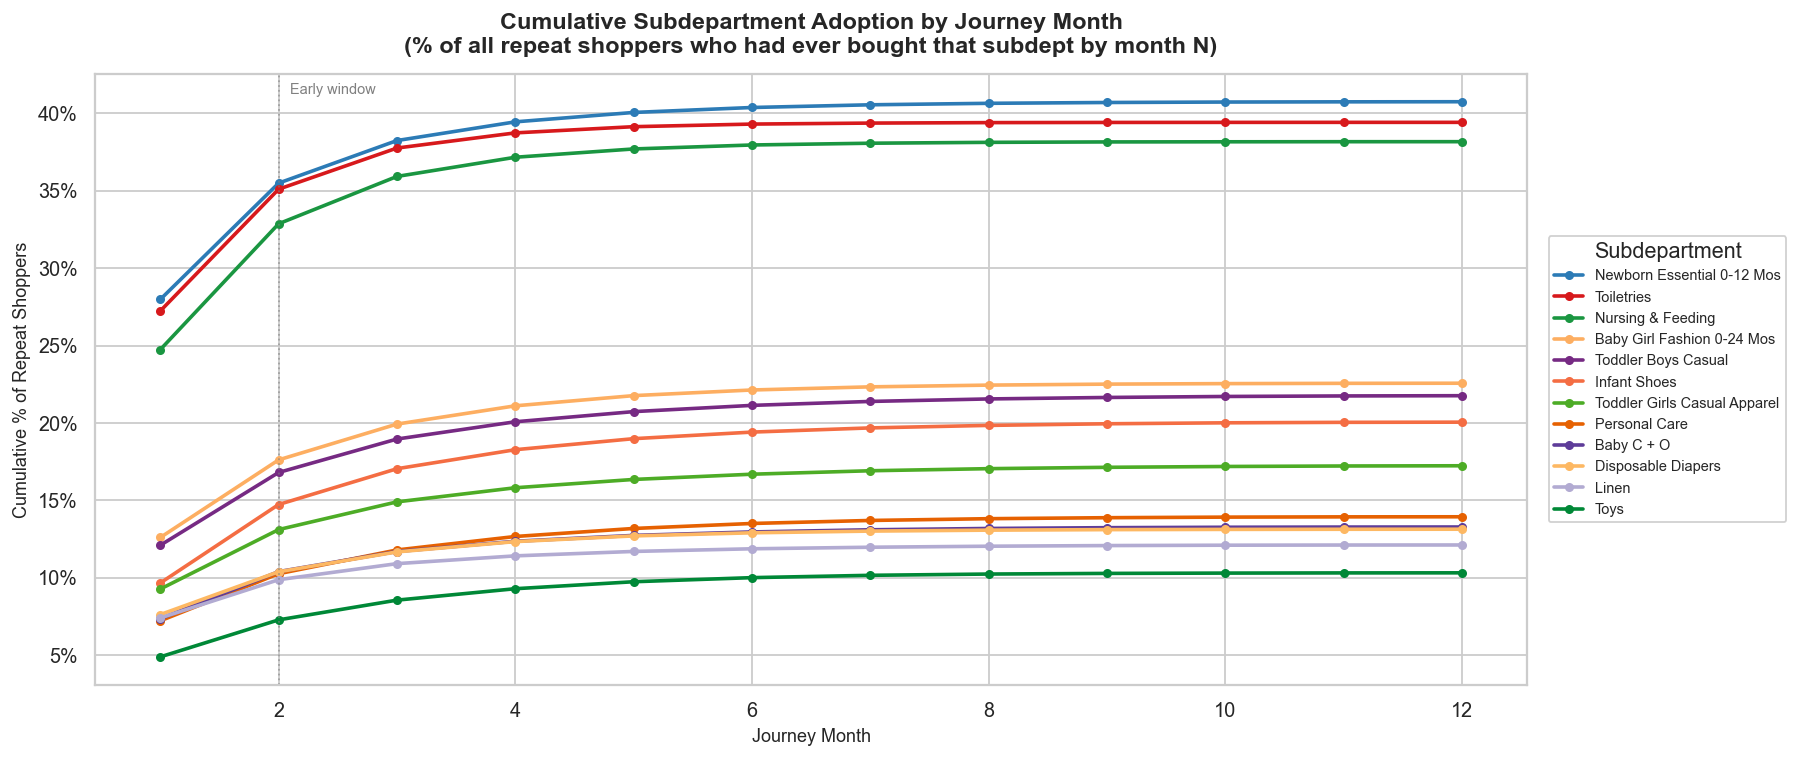

Saved: RS_11a_adoption_curves.png


In [12]:
# ── Chart A: Cumulative adoption curves ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

palette_ext = (PALETTE * 3)[:len(top_subdepts)]
for i, subdept in enumerate(top_subdepts):
    sub = adoption_curve[adoption_curve['subdepartment_cleaned'] == subdept]
    ax.plot(sub['journey_month'], sub['pct_ever_bought'],
            marker='o', markersize=4, linewidth=2,
            color=palette_ext[i], label=subdept.title())

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Cumulative Subdepartment Adoption by Journey Month\n'
             '(% of all repeat shoppers who had ever bought that subdept by month N)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Journey Month', fontsize=10)
ax.set_ylabel('Cumulative % of Repeat Shoppers', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=8, title='Subdepartment', framealpha=0.9)
ax.axvline(2, color='grey', lw=1, linestyle=':', alpha=0.6)
ax.text(2.1, ax.get_ylim()[1]*0.97, 'Early window', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('RS_11a_adoption_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: RS_11a_adoption_curves.png')

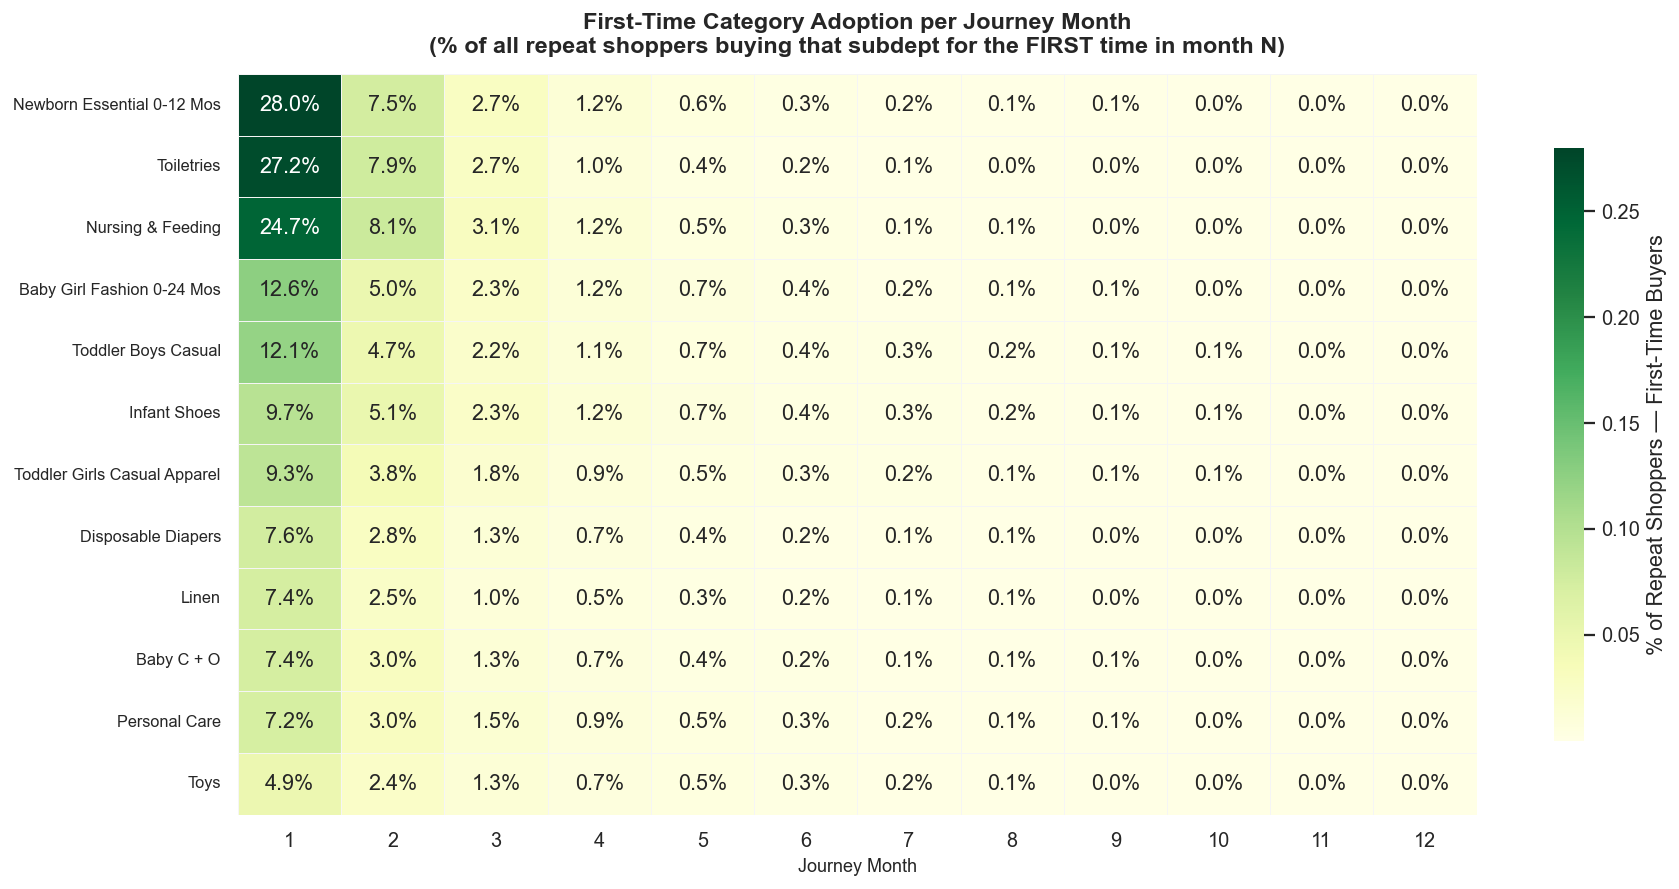

Saved: RS_11b_new_adopter_waterfall.png


In [13]:
# ── Chart B: New adopters waterfall (first-time buyers per month) ────────
waterfall_data = (
    adoption_curve[adoption_curve['subdepartment_cleaned'].isin(top_subdepts)]
    .pivot(index='subdepartment_cleaned', columns='journey_month',
           values='pct_new_this_month')
    .fillna(0)
)
waterfall_data.index = [i.title() for i in waterfall_data.index]
# Sort by month-1 adoption (entry-points at top)
waterfall_data = waterfall_data.sort_values(1, ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(waterfall_data, annot=True, fmt='.1%', cmap='YlGn',
            linewidths=0.4, linecolor='#f5f5f5',
            cbar_kws={'label':'% of Repeat Shoppers — First-Time Buyers','shrink':0.8},
            ax=ax)
ax.set_title('First-Time Category Adoption per Journey Month\n'
             '(% of all repeat shoppers buying that subdept for the FIRST time in month N)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Journey Month', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('RS_11b_new_adopter_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: RS_11b_new_adopter_waterfall.png')

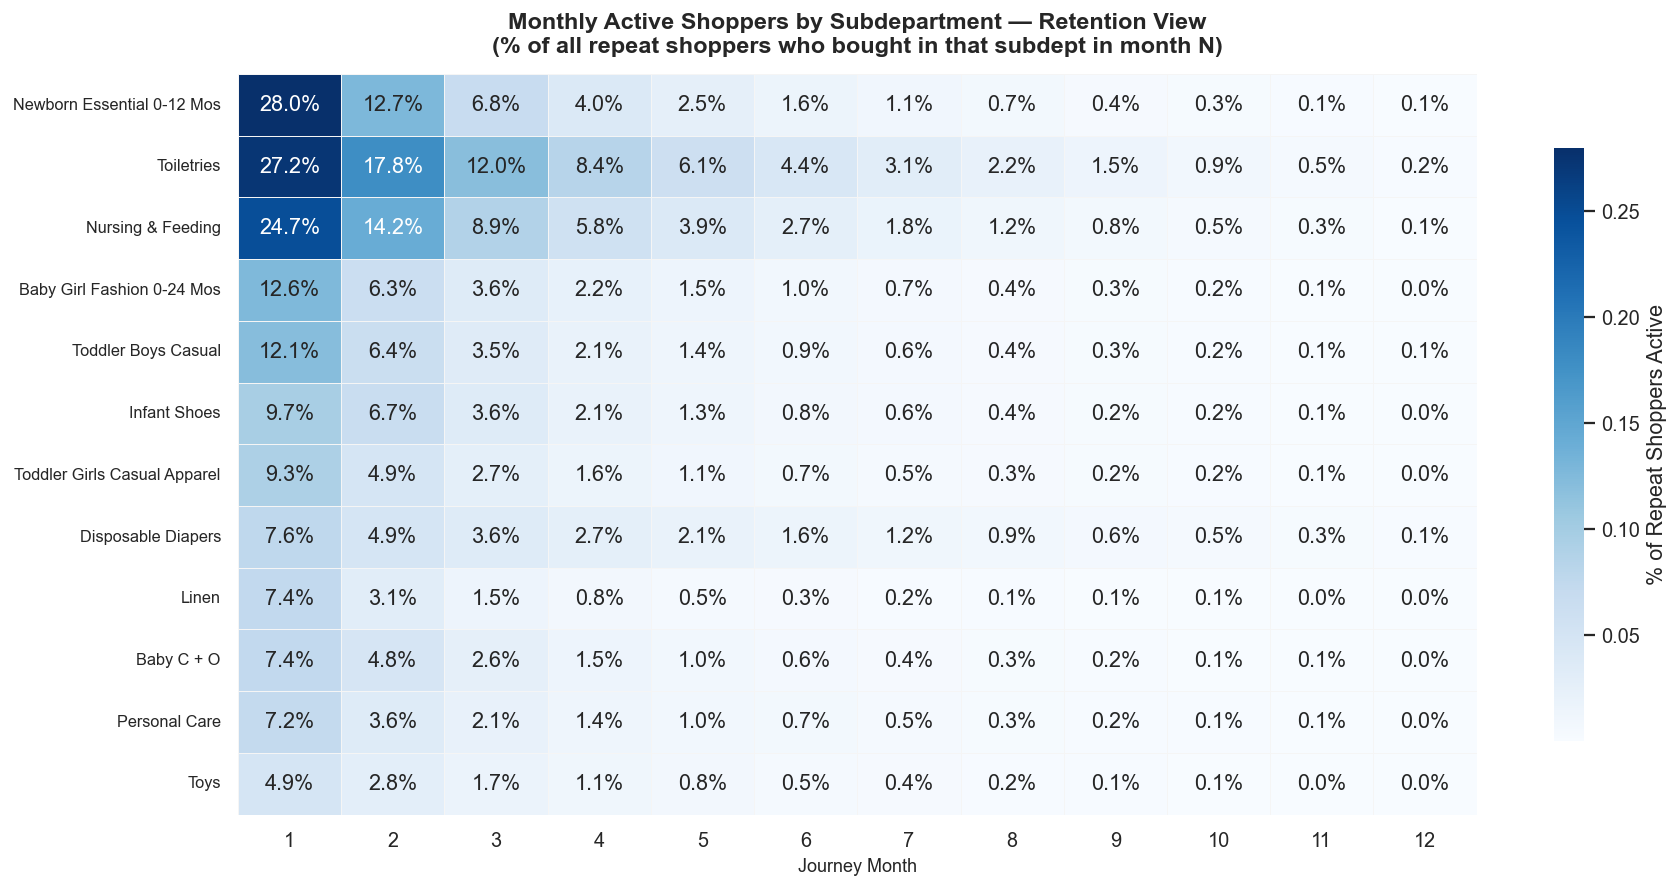

Saved: RS_11c_monthly_retention_heatmap.png


In [14]:
# ── Chart C: Monthly active shoppers heatmap (retention view) ────────────
# % of shoppers who are STILL ACTIVE in each subdept at journey month N
# (not cumulative — actual buyers that month)

active_monthly = (
    cust_month_subdept[
        cust_month_subdept['subdepartment_cleaned'].isin(top_subdepts) &
        cust_month_subdept['journey_month'].between(1, MAX_JOURNEY_MONTHS)
    ]
    .groupby(['subdepartment_cleaned','journey_month'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id':'active_shoppers'})
)
active_monthly['pct_active'] = active_monthly['active_shoppers'] / n_repeat

retention_pivot = (
    active_monthly
    .pivot(index='subdepartment_cleaned', columns='journey_month', values='pct_active')
    .fillna(0)
)
retention_pivot.index = [i.title() for i in retention_pivot.index]
# Align row order with waterfall chart (month-1 sort)
retention_pivot = retention_pivot.reindex(
    [i for i in waterfall_data.index if i in retention_pivot.index]
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_pivot, annot=True, fmt='.1%', cmap='Blues',
            linewidths=0.4, linecolor='#f5f5f5',
            cbar_kws={'label':'% of Repeat Shoppers Active','shrink':0.8},
            ax=ax)
ax.set_title('Monthly Active Shoppers by Subdepartment — Retention View\n'
             '(% of all repeat shoppers who bought in that subdept in month N)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Journey Month', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('RS_11c_monthly_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: RS_11c_monthly_retention_heatmap.png')

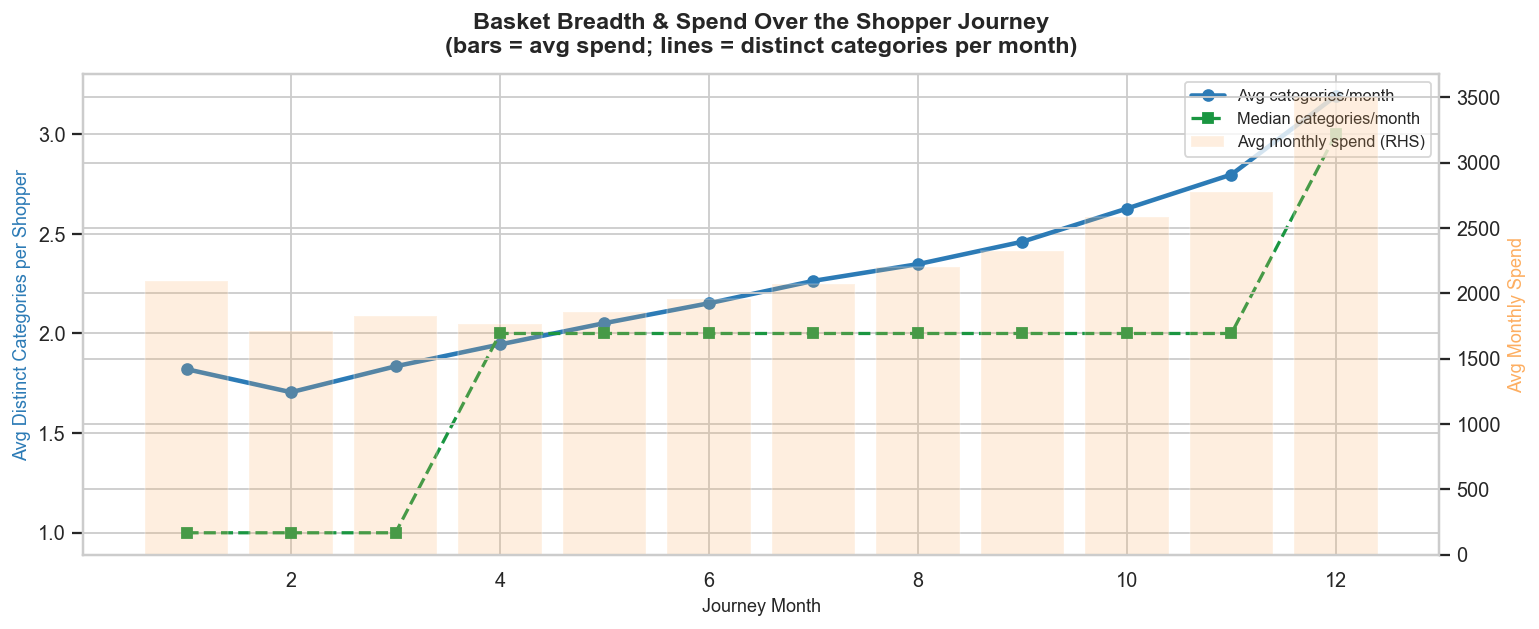

Saved: RS_11d_basket_breadth.png


In [15]:
# ── Chart D: Avg basket breadth over the journey ─────────────────────────
# How many distinct categories does the avg shopper buy per month,
# and does it grow, shrink, or plateau?

breadth = (
    seq.groupby('journey_month')
    .agg(
        avg_categories    = ('n_categories', 'mean'),
        median_categories = ('n_categories', 'median'),
        avg_spend         = ('monthly_spend', 'mean'),
        n_shoppers        = ('customer_id', 'nunique'),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(breadth['journey_month'], breadth['avg_categories'],
         'o-', color=PALETTE[0], linewidth=2.5, label='Avg categories/month')
ax1.plot(breadth['journey_month'], breadth['median_categories'],
         's--', color=PALETTE[2], linewidth=1.8, label='Median categories/month')
ax2.bar(breadth['journey_month'], breadth['avg_spend'],
        alpha=0.20, color=PALETTE[3], label='Avg monthly spend (RHS)')

ax1.set_xlabel('Journey Month', fontsize=10)
ax1.set_ylabel('Avg Distinct Categories per Shopper', fontsize=10, color=PALETTE[0])
ax2.set_ylabel('Avg Monthly Spend', fontsize=10, color=PALETTE[3])
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.set_title('Basket Breadth & Spend Over the Shopper Journey\n'
              '(bars = avg spend; lines = distinct categories per month)',
              fontsize=13, fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('RS_11d_basket_breadth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: RS_11d_basket_breadth.png')

## 8. Save Outputs

In [16]:
# ── Output A: Per-shopper monthly sequence ───────────────────────────────
seq_out = seq.merge(
    repeat_profile[['customer_id','total_spend_12m','journey_stage',
                     'top_subdept'] +
                    (['persona'] if 'persona' in repeat_profile.columns else [])],
    on='customer_id', how='left'
)
seq_out.to_parquet('shopper_monthly_sequence.parquet', index=False)
seq_out.to_csv('shopper_monthly_sequence.csv', index=False)
print(f'Saved shopper_monthly_sequence  : {seq_out.shape[0]:,} rows × {seq_out.shape[1]} cols')
print('Columns:', list(seq_out.columns))

# ── Output B: Wide category adoption matrix ───────────────────────────────
cat_matrix.to_parquet('shopper_category_matrix.parquet', index=False)
cat_matrix.to_csv('shopper_category_matrix.csv', index=False)
print(f'\nSaved shopper_category_matrix   : {cat_matrix.shape[0]:,} rows × {cat_matrix.shape[1]} cols')

# ── Output C: Aggregate adoption curve ───────────────────────────────────
adoption_curve.to_csv('aggregate_adoption_curve.csv', index=False)
print(f'\nSaved aggregate_adoption_curve  : {adoption_curve.shape[0]:,} rows')

print('\n=== ALL OUTPUTS SAVED ===')

Saved shopper_monthly_sequence  : 2,364,839 rows × 12 cols
Columns: ['customer_id', 'journey_month', 'monthly_spend', 'monthly_units', 'n_categories', 'categories_bought', 'new_categories', 'dropped_categories', 'retained_categories', 'total_spend_12m', 'journey_stage', 'top_subdept']

Saved shopper_category_matrix   : 951,713 rows × 31 cols

Saved aggregate_adoption_curve  : 297 rows

=== ALL OUTPUTS SAVED ===


## 9. Readable Shopper Journey Preview

Prints a human-readable month-by-month narrative for a sample of shoppers — directly answers *'what did shopper X buy each month and what changed?'*

In [17]:
def print_shopper_journey(customer_id, df=seq_out):
    rows = df[df['customer_id'] == customer_id].sort_values('journey_month')
    if rows.empty:
        print(f'Customer {customer_id} not found.'); return
    meta = rows.iloc[0]
    stage = meta.get('journey_stage', 'N/A')
    persona = meta.get('persona', 'N/A')
    total_spend = meta.get('total_spend_12m', 0)
    print(f'\n{"="*65}')
    print(f'  SHOPPER {customer_id}')
    print(f'  Journey stage : {stage} | Persona : {persona}')
    print(f'  Total spend   : {total_spend:,.0f}')
    print(f'{"="*65}')
    for _, r in rows.iterrows():
        m = int(r['journey_month'])
        cats    = r['categories_bought'] or '—'
        new_c   = r['new_categories']    or '—'
        drop_c  = r['dropped_categories']or '—'
        hold_c  = r['retained_categories']or '—'
        print(f'  Month {m:>2} | Spend: {r["monthly_spend"]:>8,.0f} | '
              f'Categories ({int(r["n_categories"])}): {cats}')
        if m > 1:
            print(f'           | ➕ New    : {new_c}')
            print(f'           | ➖ Dropped: {drop_c}')
            print(f'           | 🔁 Kept   : {hold_c}')
    print()

# Print journeys for a sample of shoppers
# — top 3 by total spend, 3 random mid-tier, 2 by highest category breadth
top_spenders   = seq_out.groupby('customer_id')['total_spend_12m'].first().nlargest(3).index.tolist()
mid_tier       = (seq_out[['customer_id','total_spend_12m']]
                  .drop_duplicates()
                  .sort_values('total_spend_12m')
                  .iloc[len(seq_out['customer_id'].unique())//3 :
                        len(seq_out['customer_id'].unique())//3 + 3]['customer_id'].tolist())
broadest       = (seq_out.groupby('customer_id')['n_categories']
                  .max().nlargest(2).index.tolist())

sample_ids = list(dict.fromkeys(top_spenders + mid_tier + broadest))[:8]
for cid in sample_ids:
    print_shopper_journey(cid)


  SHOPPER 278035
  Journey stage : Other | Persona : N/A
  Total spend   : 5,009,257
  Month  1 | Spend:  430,505 | Categories (1): baby c + o
  Month  2 | Spend: 2,799,584 | Categories (1): baby c + o
           | ➕ New    : —
           | ➖ Dropped: —
           | 🔁 Kept   : baby c + o
  Month  3 | Spend: 1,779,168 | Categories (1): baby c + o
           | ➕ New    : —
           | ➖ Dropped: —
           | 🔁 Kept   : baby c + o
  Month  4 | Spend: 1,079,280 | Categories (1): baby c + o
           | ➕ New    : —
           | ➖ Dropped: —
           | 🔁 Kept   : baby c + o


  SHOPPER 253241
  Journey stage : Other | Persona : N/A
  Total spend   : 4,202,301
  Month  1 | Spend:      599 | Categories (1): personal care
  Month  2 | Spend:  946,848 | Categories (1): baby c + o
           | ➕ New    : baby c + o
           | ➖ Dropped: personal care
           | 🔁 Kept   : —
  Month  3 | Spend:  177,552 | Categories (1): baby c + o
           | ➕ New    : —
           | ➖ Dropped: —
   